## 铰接模型的视线
基于模型“ RODM_Hige_study_plan_a_2.ipynb ” 在多铰接实现中存在的结果与论文结果拟合不好的问题，猜测是由于铰接连接点处为受力点。
### 本程序建立模型方案基本如下：
1、导入子模块刚度、质量矩阵。\\ 
2、区分出受力点和非受力点，将受力点做为主控制点。
3、在原矩阵中建立铰接关系，然后再进行降维。
4、将水动力系数施加到对应位置的主控制点上，构建运动方程

In [1]:
#import packages
import time
import numpy as np
import capytaine as cpt
import scipy
from capytaine.io.mesh_writers import write_STL
import matplotlib.pyplot as plt
from scipy.linalg import block_diag
from scipy.linalg import eigh
import vtk
import logging
import xarray as xr
from capytaine.io.xarray import merge_complex_values
from capytaine.post_pro import rao
logging.basicConfig(level=logging.INFO, format='%(levelname)-8s: %(message)s')
# user defined functions
import DM_ShowNodes as DMshow
import DM_Reading as dm_r
import DM_Assemble as DM_A
import SEREP as SEREP
import DM_Method as DM_M
import pandas as pd

### 为了方便调整参数形成的完整程序

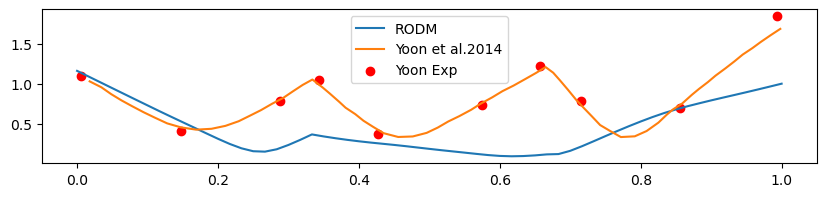

In [7]:
def input_parameters():
    # 输入文件路径
    file_m = r'E:\phd\Code\DM-FEM2D\StructureData\Yoon_hinge\Job_hinge_study_100_60_YoonModel_MASS1.mtx'
    file_k = r'E:\phd\Code\DM-FEM2D\StructureData\Yoon_hinge\Job_hinge_study_100_60_YoonModel_STIF1.mtx'
    hydro_file = r'E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoon_hinge\DM10_direction180_slender180_rho1025.nc'  # 水动力数据文件路径

    # 获取刚度矩阵和质量矩阵
    m = dm_r.get_stiffness_matrix(file_m)
    k = dm_r.get_stiffness_matrix(file_k)

    # 设置结构的数量
    n = 3  # 例如，3个结构

    # 使用相同的函数生成刚度矩阵和质量矩阵的块对角矩阵
    fem_k = create_block_matrix(k, n)
    fem_m = create_block_matrix(m, n)

    # 铰链刚度
    k_hinge = 1E20

    # 定义所有铰接节点对的列表
    hinges = [
        ([21, 42, 63, 84, 105, 126, 147, 168, 189, 210, 231, 252, 273],
         [274, 295, 316, 337, 358, 379, 400, 421, 442, 463, 484, 505, 526]),
        ([294, 315, 336, 357, 378, 399, 420, 441, 462, 483, 504, 525, 546],
         [547, 568, 589, 610, 631, 652, 673, 694, 715, 736, 757, 778, 799])
    ]

    # 主要控制节点
    older_master_nodes = sorted([130,136,142,128+273,134+273,140+273,146+273,132+273+273,138+273+273,144+273+273])
    # sorted([130,136,142,128+273,134+273,140+273,146+273,132+273+273,138+273+273,144+273+273])  # 主节点
    # sorted([144, 138, 132, 146+273, 140+273,134+273,128+273, 142+273*2,136+273*2,130+273*2])
    # master_nodes = sorted([132,142,405,415,678,688])
    # master_nodes = DM_A.calculate_node_positions(424,6,10)

    master_nodes, old_node_positions = update_master_nodes(older_master_nodes, hinges)

    # 总节点数
    num_nodes = 793 + 13 + 13
    
    # 控制选项: 使用SEREP还是Static Condensation
    use_serep = False # True表示使用SEREP，False表示使用Static Condensation

    return fem_k, fem_m, k_hinge, hinges, master_nodes, num_nodes, hydro_file, use_serep, old_node_positions


# 计算程序
# 将单个结构的刚度矩阵拼接为大的矩阵
def create_block_matrix(matrix, n):
    """
    创建一个 n 个结构的块对角矩阵。
    matrix 是单个结构的刚度或质量矩阵，n 是结构的数量。
    """
    zero_matrix = np.zeros_like(matrix)
    blocks = []

    for i in range(n):
        row_blocks = [zero_matrix] * n
        row_blocks[i] = matrix
        blocks.append(row_blocks)

    big_matrix = np.block(blocks)
    return big_matrix

def update_master_nodes(old_master_nodes, hinges):
    """
    更新主节点列表并找到老主节点在新主节点列表中的位置。

    Parameters:
    - old_master_nodes (list): 原始主节点列表。
    - hinges (list of tuple): 铰接节点的列表，每个元素是两个节点列表的元组。

    Returns:
    - tuple: 包含以下两个元素：
        1. 新主节点列表 (list)
        2. 老主节点在新主节点列表中的位置 (list)
    """
    # 展平铰接节点为单一列表
    hinge_nodes = [node for hinge in hinges for nodes in hinge for node in nodes]
    
    # 更新主节点列表，合并去重并排序
    new_master_nodes = sorted(set(old_master_nodes + hinge_nodes))
    
    # 找到老主节点在新主节点列表中的位置
    old_node_positions = sorted([new_master_nodes.index(node) for node in old_master_nodes])

    return new_master_nodes, old_node_positions


def apply_hinge_joints(fem_kiffness, k_hinge, hinges):
    """
    将铰链关节刚度矩阵应用到全局刚度矩阵中，适用于多个模块之间的铰接。

    参数:
    fem_kiffness (numpy.ndarray): 全局刚度矩阵。
    k_hinge (float): 铰链关节的刚度。
    hinges (list of tuple): 每个铰接节点对的列表，每个元组包含两个节点编号列表。

    返回:
    numpy.ndarray: 更新后的全局刚度矩阵。
    """
    # 定义铰链关节的刚度矩阵
    KC = np.diag([k_hinge, k_hinge, k_hinge, k_hinge, 1, k_hinge])
    negative_KC = -KC

    # 处理所有铰接
    for nodes_k1, nodes_k2 in hinges:
        for node1, node2 in zip(nodes_k1, nodes_k2):
            # 计算在大矩阵中的索引位置
            index1 = (node1 - 1) * 6  # K_1 节点自由度起始位置
            index2 = (node2 - 1) * 6  # K_2 节点自由度起始位置

            # 在节点自身设置 KC
            fem_kiffness[index1:index1+6, index1:index1+6] += KC
            fem_kiffness[index2:index2+6, index2:index2+6] += KC

            # 设置两节点间的相互作用 -KC
            fem_kiffness[index1:index1+6, index2:index2+6] += negative_KC
            fem_kiffness[index2:index2+6, index1:index1+6] += negative_KC
    
    return fem_kiffness

def perform_calculation(fem_k, fem_m, k_hinge, hinges, master_nodes, num_nodes, hydro_file, use_serep, old_node_positions):
    # 应用所有铰链关节到全局刚度矩阵
    fem_kiffness = apply_hinge_joints(fem_k, k_hinge, hinges)

    # 使用 SEREP 或 static_condensation 进行降阶
    fem_m_reduced = SEREP.reduce_dofs(fem_m, num_nodes, [5])
    fem_siffness_reduced = SEREP.reduce_dofs(fem_kiffness, num_nodes, [5])

    # 获取主自由度和从自由度
    MasterDofs, SlaveDofs = SEREP.separate_dofs(num_nodes, master_nodes)

    if use_serep:
        # 使用 SEREP 方法
        MR, KR, T = SEREP.SEREP(fem_siffness_reduced, fem_m_reduced, SlaveDofs, master_nodes)
    else:
        # 使用 Static Condensation 方法
        MR, KR, T = SEREP.static_condensation(fem_siffness_reduced, fem_m_reduced, MasterDofs, SlaveDofs)

    # 读取水动力数据
    dataset = merge_complex_values(xr.open_dataset(hydro_file))
    omega = dataset.omega.values
    i = 0

    # 获取水动力数据
    added_mass = dataset['added_mass'][i].values
    radiation_damping = dataset['radiation_damping'][i].values
    F_w = dataset['Froude_Krylov_force'][i].values + dataset['diffraction_force'][i].values

    # 对水动力矩阵进行降阶
    inertia_matrix = SEREP.reduce_dofs(dataset['inertia_matrix'].values, len(old_node_positions), [5])
    added_mass = SEREP.reduce_dofs(added_mass, len(old_node_positions), [5])
    radiation_damping = SEREP.reduce_dofs(radiation_damping, len(old_node_positions), [5])
    hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
    hydrostatic_stiffness = SEREP.reduce_dofs(hydrostatic_stiffness, len(old_node_positions), [5])
    F_w = SEREP.reduce_force_matrix_dofs(F_w, len(old_node_positions), 5)[::-1].reshape(1, 5 * len(old_node_positions))

    # Construct the combined matrices
    M = added_mass + inertia_matrix # Total mass fem_m inertia_matrix 
    C = radiation_damping  # Damping
    K = hydrostatic_stiffness  # Stiffness

    num_nodes = len(master_nodes)
    force_nodes = old_node_positions  #[4,10,16,23,29,35,41,48,54,60] [6,16,27,37,48,58] 
    # Insert matrices into the system
    mass = DM_A.insert_matrix(num_nodes, M, force_nodes, dof_num=5)  #+ fem_m
    damping = DM_A.insert_matrix(num_nodes, C, force_nodes, dof_num=5)
    hy_stiffness = DM_A.insert_matrix(num_nodes, K, force_nodes, dof_num=5)

    # Assemble the stiffness matrix
    stiffness = KR + hy_stiffness

    # Assemble the force matrix
    K_F_w = DM_A.extend_force_matrix(F_w, force_nodes, num_nodes, dof_num=5)

    # 频域求解
    master_displacement = DM_A.solve_frequency_domain(mass, damping, stiffness, K_F_w, omega[i])
    global_displacement_disorder = T @ master_displacement
    master_displacement = master_displacement.reshape(len(master_nodes), 5)[::-1].reshape(5 * len(master_nodes), 1)

    # 计算全局位移矩阵
    global_displacement_error = SEREP.reorder_displacement_matrix(global_displacement_disorder, MasterDofs, SlaveDofs)
    global_displacement_replace = DM_M.replace_master_with_global(master_displacement, global_displacement_error, master_nodes)

    return global_displacement_replace


def post_process(global_displacement_replace):
    mid = global_displacement_replace[2::5, :]
    
    # 假设 heave 数据已经计算并存储在 heave 变量中
    heave = abs(mid)

    # 将 heave 数据分别划分为三个模块
    model1 = heave[0:273].reshape(13, 21)  # 每个模块13x21
    model2 = heave[273:546].reshape(13, 21)
    model3 = heave[546:819].reshape(13, 21)

    # 将三个模块的模型结合在一起
    combined_model = np.hstack((model1, model2, model3))

    # 删除每个模块之间的铰接部分（删除第20列和第41列）
    modified_model = np.delete(combined_model, [20, 41], axis=1)

    # 可视化结果
    # plt.imshow(modified_model)
    # plt.colorbar()
    # plt.show()

    # 比较结果
    x = np.linspace(0, 1, 61)
    plt.figure(figsize=(10, 2))
    plt.plot(x, modified_model[7, :][::-1], label='RODM')

    # 读取并绘制其他数据
    df = pd.read_csv(r'E:\phd\Code\DM-FEM2D\FEM_Reduce\Hinge\Yoon_numerical_0_2.csv', header=None)
    plt.plot(df.iloc[:, 0], df.iloc[:, 1], label='Yoon et al.2014')

    df2 = pd.read_csv(r'E:\phd\Code\DM-FEM2D\FEM_Reduce\Hinge\Yoon_exp.csv', header=None)
    plt.scatter(df2.iloc[:, 0], df2.iloc[:, 1], color='red', label='Yoon Exp')
    
    plt.legend()
    # plt.ylim(0.2, 1.8)
    plt.show()

def main():
    # 参数输入
    fem_k, fem_m, k_hinge, hinges, master_nodes, num_nodes, hydro_file, use_serep, old_node_positions = input_parameters()
    
    # 计算程序
    global_displacement_replace = perform_calculation(fem_k, fem_m, k_hinge, hinges, master_nodes, num_nodes, hydro_file, use_serep, old_node_positions)
    
    # 后处理
    post_process(global_displacement_replace)

if __name__ == "__main__":
    main()


In [3]:


# 示例调用
old_master_nodes = [144, 138, 132, 146 + 273, 140 + 273, 134 + 273, 128 + 273, 
                    142 + 273 * 2, 136 + 273 * 2, 130 + 273 * 2]

hinges = [
    ([21, 42, 63, 84, 105, 126, 147, 168, 189, 210, 231, 252, 273],
     [274, 295, 316, 337, 358, 379, 400, 421, 442, 463, 484, 505, 526]),
    ([294, 315, 336, 357, 378, 399, 420, 441, 462, 483, 504, 525, 546],
     [547, 568, 589, 610, 631, 652, 673, 694, 715, 736, 757, 778, 799])
]

# 获取结果
master_nodes, old_node_positions = update_master_nodes(old_master_nodes, hinges)




In [4]:
len(old_node_positions)

10

In [5]:
len(master_nodes)

62

In [6]:
old_node_positions

[6, 7, 8, 29, 30, 31, 32, 53, 54, 55]